# QuadTree

In [ ]:
import math
import random


MIN_SIZE = 1  # metros


#
# Nodo
#
class Nodo:
    def __init__(self, x, y, w, h, capacidad):
        self.x = x #centro x
        self.y = y #centro y
        self.w = w #ancho
        self.h = h #alto
        self.capacidad = capacidad #capacidad por nodo (1 en este caso)

        self.puntos = []
        self.dividido = False

        self.nw = None # nodo izq-arr
        self.ne = None # nodo der-arr
        self.sw = None # nodo izq-aba
        self.se = None # nodo der-aba


#
# Contención
#
def contiene(nodo, punto):
    px, py = punto
    return (nodo.x - nodo.w <= px <= nodo.x + nodo.w and
            nodo.y - nodo.h <= py <= nodo.y + nodo.h)


#
# Distancia
#
def distancia(a, b):
    dx = a[0] - b[0]
    dy = a[1] - b[1]
    return math.sqrt(dx*dx + dy*dy)


#
# Distancia de punto a nodo
#
def distancia_a_nodo(nodo, punto):
    px, py = punto

    dx = max(abs(px - nodo.x) - nodo.w, 0)
    dy = max(abs(py - nodo.y) - nodo.h, 0)

    return math.sqrt(dx*dx + dy*dy)


#
# Subdividir
#
def subdividir(nodo):
    x, y = nodo.x, nodo.y
    w, h = nodo.w / 2, nodo.h / 2

    nodo.nw = Nodo(x - w, y - h, w, h, nodo.capacidad)
    nodo.ne = Nodo(x + w, y - h, w, h, nodo.capacidad)
    nodo.sw = Nodo(x - w, y + h, w, h, nodo.capacidad)
    nodo.se = Nodo(x + w, y + h, w, h, nodo.capacidad)

    nodo.dividido = True


#
# Insertar
#
def insertar(nodo, punto):
    if not contiene(nodo, punto):
        return False

    # condición de parada por tamaño mínimo
    if nodo.w < MIN_SIZE and nodo.h < MIN_SIZE:
        nodo.puntos.append(punto)
        return True

    # si aún hay espacio
    if len(nodo.puntos) < nodo.capacidad:
        nodo.puntos.append(punto)
        return True

    # subdividir si es necesario
    if not nodo.dividido:
        subdividir(nodo)

        puntos_viejos = nodo.puntos
        nodo.puntos = []

        for p in puntos_viejos:
            insertar(nodo, p)

    # insertar en hijos
    return (insertar(nodo.nw, punto) or
            insertar(nodo.ne, punto) or
            insertar(nodo.sw, punto) or
            insertar(nodo.se, punto))


#
# Intersección círculo-rectángulo
#
def intersecta(nodo, centro, radio):
    cx, cy = centro

    dx = max(abs(cx - nodo.x) - nodo.w, 0)
    dy = max(abs(cy - nodo.y) - nodo.h, 0)

    return dx*dx + dy*dy <= radio*radio


#
# Búsqueda por radio
#
def en_radio_quadtree(nodo, centro, radio, resultado):
    if nodo is None:
        return

    # poda
    if not intersecta(nodo, centro, radio):
        return

    # revisar puntos
    for p in nodo.puntos:
        if distancia(p, centro) <= radio:
            resultado.append(p)

    # bajar a hijos
    if nodo.dividido:
        en_radio_quadtree(nodo.nw, centro, radio, resultado)
        en_radio_quadtree(nodo.ne, centro, radio, resultado)
        en_radio_quadtree(nodo.sw, centro, radio, resultado)
        en_radio_quadtree(nodo.se, centro, radio, resultado)


#
# Vecino más cercano
#
def nearest_quadtree(nodo, objetivo, mejor=None, mejor_dist=float("inf")):
    if nodo is None:
        return mejor, mejor_dist

    # poda
    if distancia_a_nodo(nodo, objetivo) > mejor_dist:
        return mejor, mejor_dist

    # revisar puntos
    for p in nodo.puntos:
        d = distancia(objetivo, p)
        if d < mejor_dist:
            mejor = p
            mejor_dist = d

    # revisar hijos ordenados por cercanía
    if nodo.dividido:
        hijos = [nodo.nw, nodo.ne, nodo.sw, nodo.se]
        hijos.sort(key=lambda n: distancia_a_nodo(n, objetivo))

        for h in hijos:
            mejor, mejor_dist = nearest_quadtree(h, objetivo, mejor, mejor_dist)

    return mejor, mejor_dist


#
# Construir árbol
#
def construir_quadtree(puntos):
    xs = [p[0] for p in puntos]
    ys = [p[1] for p in puntos]

    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    x_centro = (xmin + xmax) / 2
    y_centro = (ymin + ymax) / 2

    padding = 10  # metros

    w = (xmax - xmin) / 2 + padding
    h = (ymax - ymin) / 2 + padding

    root = Nodo(x_centro, y_centro, w, h, capacidad=1)

    for p in puntos:
        insertar(root, p)

    return root

#Fuerza Bruta

In [ ]:
#
# Cercano fuerza bruta
#
def nearest_bruteforce(puntos, objetivo):
    mejor = None
    mejor_dist = float("inf")

    for p in puntos:
        d = distancia(objetivo, p)
        if d < mejor_dist:
            mejor_dist = d
            mejor = p

    return mejor

#
# Radio fuerza bruta
#
def en_radio_bruteforce(puntos, centro, radio):
    return [p for p in puntos if distancia(p, centro) <= radio]

#Generación de datos

In [ ]:
#
# Generador de datos
#
def generar_puntos(n=100, seed=42):
    random.seed(seed)

    puntos = []

    for _ in range(n):
        x = random.uniform(-5000, 5000)  # metros
        y = random.uniform(-5000, 5000)
        puntos.append((x, y))

    return puntos

#Pruebas unitarias

**Test 1: ejecución general**
Este test verifica que el QuadTree funcione correctamente con datos aleatorios. Se generan puntos en una zona, se construye el árbol y se hacen dos consultas: encontrar el vecino más cercano y buscar puntos dentro de un radio. No valida resultados exactos, solo que el algoritmo se ejecute sin errores y devuelva resultados coherentes.

**Test 2: punto exacto**
Este test comprueba que si el punto de consulta existe exactamente en el conjunto de datos, el algoritmo de vecino más cercano lo devuelve correctamente. Es una validación básica de precisión.

**Test 3: estabilidad**
Este test verifica que el resultado de la búsqueda del vecino más cercano sea consistente. Se ejecuta varias veces la misma consulta y se espera que siempre devuelva el mismo punto. Esto asegura que el algoritmo no tenga comportamientos aleatorios o inconsistentes.

In [ ]:
#
# Test 1: ejecución básica
#
def test_ejecucion_quadtree():
    puntos = [
        (
            random.uniform(-5000, 5000),  # metros
            random.uniform(-5000, 5000)
        )
        for _ in range(200)
    ]

    arbol = construir_quadtree(puntos)

    consulta = (0, 0)  # centro

    print("Nearest:", nearest_quadtree(arbol, consulta)[0])

    resultado = []
    en_radio_quadtree(arbol, consulta, 500, resultado)  # 500 metros
    print("Radio:", len(resultado), "puntos encontrados")

#
# Test 2: punto exacto
#
def test_punto_exacto_quadtree():
    puntos = [(1, 1), (2, 2), (3, 3)]
    arbol = construir_quadtree(puntos)

    consulta = (2, 2)
    resultado, _ = nearest_quadtree(arbol, consulta)

    assert resultado == (2, 2)
    print("Test punto exacto OK")

#
# Test 3: estabilidad
#
def test_estabilidad_quadtree():
    puntos = [(random.uniform(0, 1000), random.uniform(0, 1000)) for _ in range(100)]
    arbol = construir_quadtree(puntos)

    consulta = (450, 670)

    resultados = {nearest_quadtree(arbol, consulta)[0] for _ in range(10)}

    assert len(resultados) == 1
    print("Nearest es estable (QuadTree)")

#
# Ejecutar tests
#
test_ejecucion_quadtree()
test_punto_exacto_quadtree()
test_estabilidad_quadtree()

Nearest: (427.3154201434936, -73.61828972046533)
Radio: 2 puntos encontrados
Test punto exacto OK
Nearest es estable (QuadTree)


# Visualización

En este bloque se pueden hacer las pruebas específicas para poder visualizar donde quedaría el punto a consultar y los más cercanos en el radio elegido.

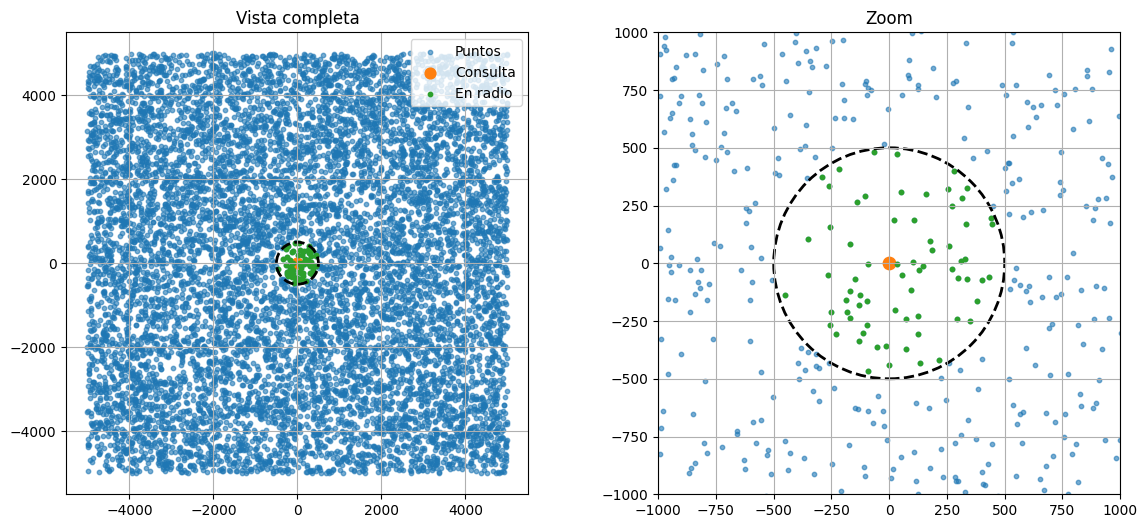

In [ ]:
import matplotlib.pyplot as plt

def visualizar_normal_y_zoom(puntos, consulta, radio_puntos=None, radio=None, zoom=1000):
    xs = [p[0] for p in puntos]
    ys = [p[1] for p in puntos]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # ─────────────────────────────
    # GRÁFICO NORMAL
    # ─────────────────────────────
    axes[0].scatter(xs, ys, s=10, alpha=0.6, label="Puntos")
    axes[0].scatter(consulta[0], consulta[1], s=60, label="Consulta")

    if radio_puntos:
        xr = [p[0] for p in radio_puntos]
        yr = [p[1] for p in radio_puntos]
        axes[0].scatter(xr, yr, s=10, label="En radio")

    if radio:
        circle = plt.Circle(
            (consulta[0], consulta[1]),
            radio,  # YA está en metros
            fill=False,
            linestyle="--",
            linewidth=2
        )
        axes[0].add_patch(circle)

    axes[0].set_title("Vista completa")
    axes[0].legend()
    axes[0].grid(True)
    axes[0].set_aspect("equal", adjustable="box")

    # ─────────────────────────────
    # ZOOM
    # ─────────────────────────────
    axes[1].scatter(xs, ys, s=10, alpha=0.6)
    axes[1].scatter(consulta[0], consulta[1], s=80)

    if radio_puntos:
        xr = [p[0] for p in radio_puntos]
        yr = [p[1] for p in radio_puntos]
        axes[1].scatter(xr, yr, s=10)

    if radio:
        circle = plt.Circle(
            (consulta[0], consulta[1]),
            radio,
            fill=False,
            linestyle="--",
            linewidth=2
        )
        axes[1].add_patch(circle)

    # zoom ahora en METROS
    axes[1].set_xlim(consulta[0] - zoom, consulta[0] + zoom)
    axes[1].set_ylim(consulta[1] - zoom, consulta[1] + zoom)

    axes[1].set_title("Zoom")
    axes[1].grid(True)
    axes[1].set_aspect("equal", adjustable="box")

    plt.show()

# Generar datos
puntos = generar_puntos(n=10000)

# Construir QuadTree
arbol = construir_quadtree(puntos)
###################################################################
# Punto de consulta (en metros)
#############################################################
consulta = (0, 0)
##################################################33
# Radio (en metros)
####################################################
radio = 500

# Buscar
resultado = []
en_radio_quadtree(arbol, consulta, radio, resultado)

# Visualizar (SIN conversiones)
visualizar_normal_y_zoom(
    puntos,
    consulta,
    radio_puntos=resultado,
    radio=radio,
    zoom=1000   # zoom en metros
)

#Medición de tiempos

In [ ]:
import time

# ─────────────────────────────
# Comparación Nearest (QuadTree vs Brute)
# ─────────────────────────────
def medir_nearest_quadtree(puntos, consulta):
    # Construcción QuadTree
    t0 = time.perf_counter()
    arbol = construir_quadtree(puntos)
    t1 = time.perf_counter()

    # QuadTree
    t2 = time.perf_counter()
    r_qt, _ = nearest_quadtree(arbol, consulta)
    t3 = time.perf_counter()

    # Fuerza bruta
    t4 = time.perf_counter()
    r_brute = nearest_bruteforce(puntos, consulta)
    t5 = time.perf_counter()

    return {
        "build_qt": t1 - t0,
        "qt_time": t3 - t2,
        "brute_time": t5 - t4,
    }


# ─────────────────────────────
# Comparación Radio (QuadTree vs Brute)
# ─────────────────────────────
def medir_radio_quadtree(puntos, consulta, radio):
    # Construir árbol UNA vez (importante)
    arbol = construir_quadtree(puntos)

    # QuadTree
    resultado_qt = []
    t1 = time.perf_counter()
    en_radio_quadtree(arbol, consulta, radio, resultado_qt)
    t2 = time.perf_counter()

    # Fuerza bruta
    t3 = time.perf_counter()
    resultado_brute = en_radio_bruteforce(puntos, consulta, radio)
    t4 = time.perf_counter()

    return {
        "qt_time": t2 - t1,
        "brute_time": t4 - t3,
        "cantidad": len(resultado_qt),
    }

#Prueba comparación

In [ ]:
import time

#─────────────────────────────
# Prueba cercano
#─────────────────────────────
tamaños = [100, 500, 1000, 5000, 10000]

resultados_nearest_qt = []

for n in tamaños:
    puntos = generar_puntos(n=n)
    consulta = puntos[0]

    res = medir_nearest_quadtree(puntos, consulta)
    res["n"] = n

    resultados_nearest_qt.append(res)

# Mostrar resultados
print("\nRESULTADOS VECINO CERCANO")
print("n\tBuildQT\t\tQT\t\tBrute")
print("-"*90)

for r in resultados_nearest_qt:
    print(f"{r['n']}\t{r['build_qt']:.6f}\t{r['qt_time']:.6f}\t{r['brute_time']:.6f}")


#─────────────────────────────
# Prueba radio (n fijo)
#─────────────────────────────
n = 10000
radios = [500, 1000, 3000, 5000, 7000]

resultados_radio_qt = []

# Generar datos una sola vez
puntos = generar_puntos(n=n)
consulta = puntos[0]

# Construir árbol una sola vez
arbol = construir_quadtree(puntos)

for r in radios:
    # QuadTree
    resultado_qt = []
    t1 = time.perf_counter()
    en_radio_quadtree(arbol, consulta, r, resultado_qt)
    t2 = time.perf_counter()

    # Fuerza bruta
    t3 = time.perf_counter()
    resultado_brute = en_radio_bruteforce(puntos, consulta, r)
    t4 = time.perf_counter()

    resultados_radio_qt.append({
        "radio": r,
        "qt_time": t2 - t1,
        "brute_time": t4 - t3,
        "cantidad": len(resultado_qt),
    })

# Mostrar resultados
print("\nRESULTADOS RADIO")
print("Radio\tQT\t\tBrute\t\tPuntos")
print("-"*100)

for r in resultados_radio_qt:
    print(f"{r['radio']}\t{r['qt_time']:.6f}\t{r['brute_time']:.6f}\t{r['cantidad']}")


RESULTADOS VECINO CERCANO
n	BuildQT		QT		Brute
------------------------------------------------------------------------------------------
100	0.000928	0.000035	0.000020
500	0.002377	0.000038	0.000081
1000	0.006724	0.000069	0.000286
5000	0.079773	0.000054	0.000827
10000	0.062062	0.000055	0.001609

RESULTADOS RADIO
Radio	QT		Brute		Puntos
----------------------------------------------------------------------------------------------------
500	0.000233	0.002308	61
1000	0.000387	0.001797	184
3000	0.003100	0.001854	1580
5000	0.006923	0.001933	3794
7000	0.010648	0.001933	6336


#Gráfica

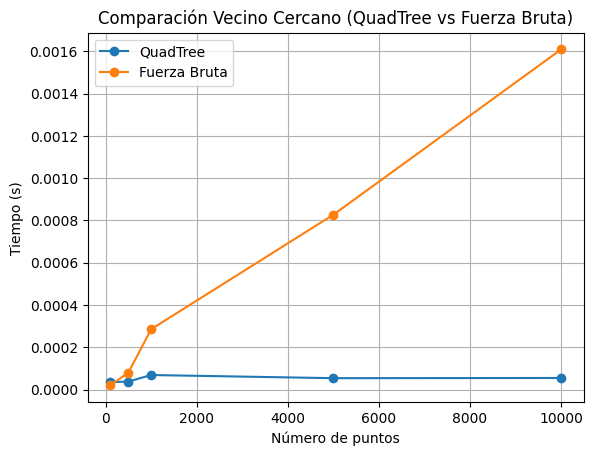

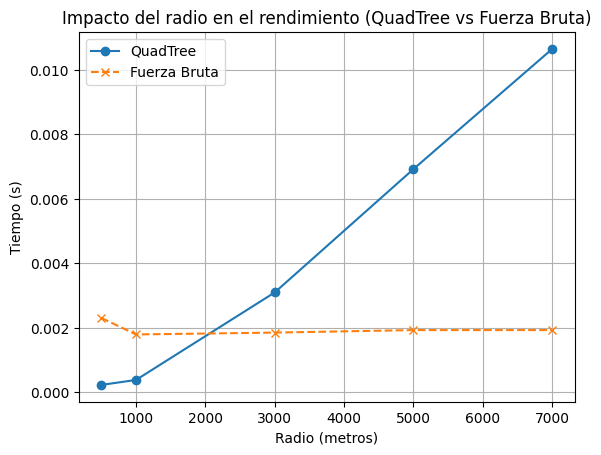

In [ ]:
def graficar_nearest_quadtree(resultados):
    import matplotlib.pyplot as plt

    xs = [r["n"] for r in resultados]
    qt = [r["qt_time"] for r in resultados]
    brute = [r["brute_time"] for r in resultados]

    plt.figure()

    plt.plot(xs, qt, marker='o', label="QuadTree")
    plt.plot(xs, brute, marker='o', label="Fuerza Bruta")

    plt.xlabel("Número de puntos")
    plt.ylabel("Tiempo (s)")
    plt.title("Comparación Vecino Cercano (QuadTree vs Fuerza Bruta)")
    plt.legend()
    plt.grid(True)

    plt.show()


# Usar:
graficar_nearest_quadtree(resultados_nearest_qt)

def graficar_radio_quadtree(resultados):
    import matplotlib.pyplot as plt

    radios = []
    qt = []
    brute = []

    for r in resultados:
        radios.append(r["radio"])
        qt.append(r["qt_time"])
        brute.append(r["brute_time"])

    # Ordenar por radio
    radios, qt, brute = zip(*sorted(zip(radios, qt, brute)))

    plt.figure()

    plt.plot(radios, qt, marker='o', label="QuadTree")
    plt.plot(radios, brute, linestyle='--', marker='x', label="Fuerza Bruta")

    plt.xlabel("Radio (metros)")
    plt.ylabel("Tiempo (s)")
    plt.title("Impacto del radio en el rendimiento (QuadTree vs Fuerza Bruta)")
    plt.legend()
    plt.grid(True)

    plt.show()


# Usar:
graficar_radio_quadtree(resultados_radio_qt)



#Análisis

###**¿Para que tamaño de datos el arbol-Quadtree comienza a ser mas rapido que "fuerza bruta"(no arboles, si listas, ...)?**

El QuadTree comienza a ser más rápido que la fuerza bruta en la búsqueda de vecino más cercano aproximadamente a partir de n = 500 puntos. Antes de eso (por ejemplo en n = 100), la fuerza bruta es más rápida porque el costo de recorrer todos los puntos es muy bajo y no compensa el uso de una estructura más compleja. A partir de n = 500, el tiempo de la fuerza bruta empieza a crecer de forma proporcional al número de puntos, mientras que el QuadTree mantiene un tiempo de consulta prácticamente constante.

**Nota:** Esto teniendo en cuenta que sea con datos estáticos o sea un árbol que se crea una vez y no se modifica ni se tiene que crear de nuevo.


###**Análisis Vecino Cercano**

El tiempo de construcción del QuadTree aumenta considerablemente con el número de puntos, siendo más costoso que otras estructuras debido a la gran cantidad de subdivisiones (capacidad 1). Sin embargo, el tiempo de búsqueda se mantiene prácticamente constante. En contraste, la fuerza bruta incrementa su tiempo de búsqueda conforme crecen los datos. Esto muestra que el QuadTree también escala mejor para consultas repetidas, aunque con un costo de construcción más alto.

###**Análisis Radio**

El rendimiento del QuadTree depende fuertemente del tamaño del radio. Con radios pequeños es eficiente porque puede descartar muchas regiones del espacio. Sin embargo, a medida que el radio crece, el árbol debe recorrer más nodos, y debido a su alta subdivisión, esto implica muchas llamadas recursivas. Cuando el radio incluye una gran parte o todos los puntos, el QuadTree se vuelve más lento que la fuerza bruta, ya que termina recorriendo prácticamente toda la estructura.

###**Conclusión**

El QuadTree es eficiente para búsquedas locales y consultas de vecino más cercano, pero su alto costo de construcción y su profundidad (debido a capacidad 1) afectan su rendimiento. Además, pierde ventaja en búsquedas por radio grandes, donde la fuerza bruta resulta más eficiente.